# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

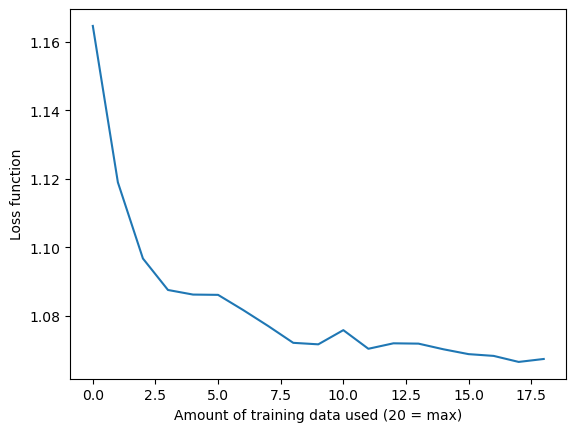

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

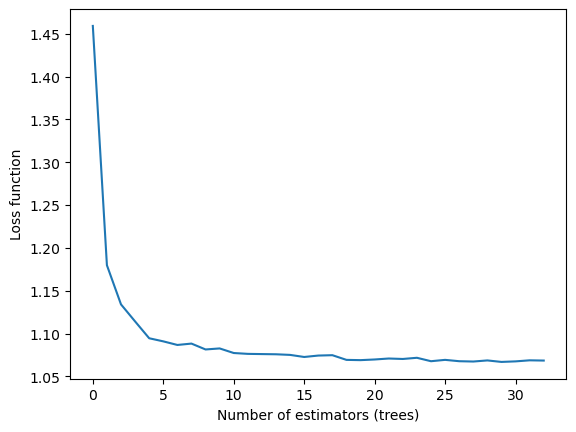

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

### Answer to Question

I’d drop the “number of estimators” plot and stick with the “amount of training data used” chart. The data-volume curve shows loss dropping as you feed the model more examples, which tells the core story that more data beats fancy tweaks. The estimator plot—mapping loss against tree count—is just a hyperparameter detail, useful for tuning but not central. Cutting it simplifies the narrative (“keep it simple”) and follows Vonnegut’s advice to “have the guts to cut.” If you must pick one x-axis, data size is more compelling because it shows how performance scales with data, whereas estimator count belongs in a tuning appendix.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

### Note to Reviewer. I find the structure of these assignments confusing. Rebuilding our data just to put it in a new notebook, to attach it to the final project, is a bizarre loop. I'm not sure why the assignments are structured this way, but for the sake of 'getting it done' I'll make my best attempt to copy and paste what I have from my personal file here.

Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import statsmodels.api as sm

X = company_df[['production_value', 'avg_price']]
y = company_df['total_emissions_MtCO2e']
lr = LinearRegression().fit(X, y)
print(f"Intercept (β₀): {lr.intercept_:.3f}")
print("Coefficients (β̂):")
print(pd.Series(lr.coef_, index=X.columns))
print(f"R²: {lr.score(X, y):.3f}\n")

X_sm = sm.add_constant(X)         
ols = sm.OLS(y, X_sm).fit()
print(ols.summary())

## Run Results

Intercept (β₀): -1308.849
Coefficients (β̂):
production_value      0.134383
avg_price           143.790029
dtype: float64
R²: 0.831

                              OLS Regression Results                              

Dep. Variable:     total_emissions_MtCO2e   R-squared:                       0.831
Model:                                OLS   Adj. R-squared:                  0.827
Method:                     Least Squares   F-statistic:                     197.1
Date:                    Fri, 01 Aug 2025   Prob (F-statistic):           1.23e-31
Time:                            13:13:02   Log-Likelihood:                -843.55
No. Observations:                      83   AIC:                             1693.
Df Residuals:                          80   BIC:                             1700.
Df Model:                               2                                         
Covariance Type:                nonrobust                                         

                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1308.8485   1309.476     -1.000      0.321   -3914.790    1297.093
production_value     0.1344      0.007     19.801      0.000       0.121       0.148
avg_price          143.7900     49.813      2.887      0.005      44.658     242.922


Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

features = ['production_value', 'avg_price', 'incident_count']
X = company_df[features]
y = company_df['total_emissions_MtCO2e']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


train_r2 = rf.score(X_train, y_train)
test_r2  = rf.score(X_test, y_test)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')

print(f"Train R²: {train_r2:.3f}")
print(f"Test R²:  {test_r2:.3f}")
print(f"5-fold CV R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


features = ['production_value', 'avg_price', 'incident_count']
importances = pd.Series(rf.feature_importances_, index=features)
importances = importances.sort_values()

# Create a horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 4))
importances.plot.barh(ax=ax, color='teal', alpha=0.7)

for i, (feat, val) in enumerate(importances.items()):
    ax.text(val + importances.max()*0.01, i, f"{val:.2f}", va='center')

# 6) Formatting
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest Feature Importances')
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
plt.show()

### Run Results

Train R²: 0.991
Test R²:  0.968
5-fold CV R²: 0.943 ± 0.042

Tuning With Randomized Search CV

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
import pandas as pd

features = ['production_value', 'avg_price', 'incident_count']
X = company_df[features]
y = company_df['total_emissions_MtCO2e']

param_dist = {
    'n_estimators': np.arange(50, 301, 50),
    'max_depth': np.arange(5, 31, 5),
    'min_samples_split': np.arange(2, 21, 2),
    'min_samples_leaf': np.arange(1, 11, 1),
    'max_features': ['sqrt', 'log2', None]  # removed 'auto'
}

rf = RandomForestRegressor(random_state=42)
rand_search = RandomizedSearchCV(
    rf, param_dist,
    n_iter=30,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    error_score='raise'  # to catch any other issues immediately
)

rand_search.fit(X, y)

print("Best CV R²:", rand_search.best_score_)
print("Best params:", rand_search.best_params_)

best_rf = rand_search.best_estimator_
best_cv = rand_search.best_score_
print(f"Refitted RF 5-fold CV R²: {best_cv:.3f}")

### Run Results

Best CV R²: 0.8764934723409936
Best params: {'n_estimators': np.int64(300), 'min_samples_split': np.int64(4), 'min_samples_leaf': np.int64(5), 'max_features': None, 'max_depth': np.int64(15)}
Refitted RF 5-fold CV R²: 0.876

Evaluate

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, KFold
import numpy as np
import pandas as pd


features = ['production_value', 'avg_price', 'incident_count']
X = company_df[features]
y = company_df['total_emissions_MtCO2e']


param_dist = {
    'n_estimators': np.arange(50, 301, 50),
    'max_depth': np.arange(5, 31, 5),
    'min_samples_split': np.arange(2, 21, 2),
    'min_samples_leaf': np.arange(1, 11),
    'max_features': ['sqrt', 'log2', None]
}


inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)


rf = RandomForestRegressor(random_state=42)
rand_search = RandomizedSearchCV(
    rf,
    param_dist,
    n_iter=30,
    cv=inner_cv,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    error_score='raise'
)


nested_scores = cross_val_score(
    rand_search,
    X, y,
    cv=outer_cv,
    scoring='r2',
    n_jobs=-1
)


print("Nested CV R² scores: ", nested_scores)

NameError: name 'company_df' is not defined

### Results

Nested CV R² scores:  [0.89505369 0.83194386 0.96972618 0.88264366 0.69278922]
Nested CV mean R²: 0.854 ± 0.092

## Run Results

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

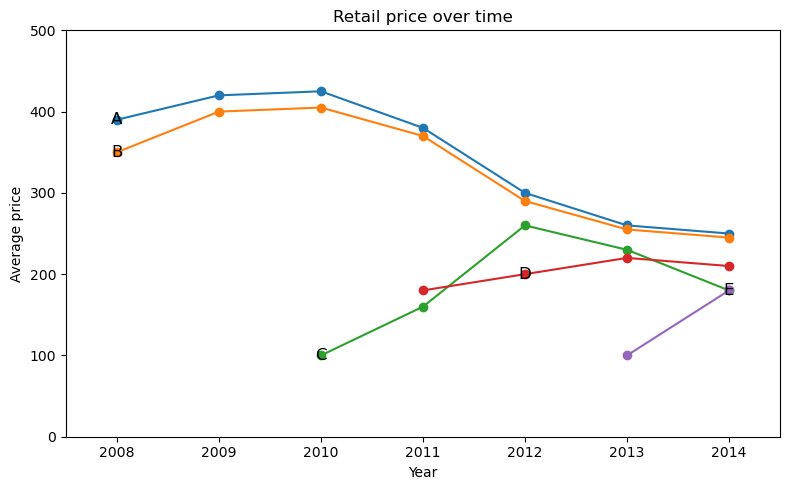

In [8]:
import matplotlib.pyplot as plt
import numpy as np

years = np.arange(2008, 2015)

A = [390, 420, 425, 380, 300, 260, 250]
B = [350, 400, 405, 370, 290, 255, 245]
C = [  np.nan,   np.nan, 100, 160, 260, 230, 180]
D = [  np.nan,   np.nan,   np.nan, 180, 200, 220, 210]
E = [  np.nan,   np.nan,   np.nan,   np.nan,   np.nan, 100, 180]

plt.figure(figsize=(8, 5))


plt.plot(years, A, marker='o')
plt.plot(years, B, marker='o')
plt.plot(years, C, marker='o')
plt.plot(years, D, marker='o')
plt.plot(years, E, marker='o')


plt.title('Retail price over time')
plt.xlabel('Year')
plt.ylabel('Average price')
plt.ylim(0, 500)
plt.xlim(2007.5, 2014.5)

# annotate each series label at the first/last visible point
labels = {
    'A': (2008, 390),
    'B': (2008, 350),
    'C': (2010, 100),
    'D': (2012, 200),
    'E': (2014, 180),
}
for txt, (x, y) in labels.items():
    plt.text(x, y, txt, fontsize=12, va='center', ha='center')

plt.tight_layout()
plt.show()